In [1]:
! pip install matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r'C:\Users\QC#\Downloads\netflix Data set.csv')

In [4]:
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [7]:
df[df=='Not Given'].count()

show_id            0
type               0
title              0
director        2588
country          287
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
dtype: int64

In [8]:
df.replace('Not Given',np.nan, inplace=True)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,NaN,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,NaN,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,NaN,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,NaN,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


In [9]:
df.isna().sum()

show_id            0
type               0
title              0
director        2588
country          287
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
dtype: int64

In [10]:
df_split=df['duration'].str.split(' ',expand=True)
df['duration_value']=df_split[0]
df['duration_unit']=df_split[1]
df['duration_value']=pd.to_numeric(df['duration_value'],errors='coerce')
df['duration_unit'].str.strip()
df['movie_duration_minute']=np.where(df['duration_unit']=='min',df['duration_value'],np.nan)
df['movie_season']=np.where(df['duration_unit'].str.contains('Season',na=False,case=False),df['duration_value'],np.nan)

In [11]:
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit,movie_duration_minute,movie_season
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries,90,min,90.0,NaN
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Season,NaN,1.0
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,Season,NaN,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min,91.0,NaN
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min,125.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,NaN,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas",2,Seasons,NaN,2.0
8786,s8798,TV Show,Zak Storm,NaN,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV,3,Seasons,NaN,3.0
8787,s8801,TV Show,Zindagi Gulzar Hai,NaN,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",1,Season,NaN,1.0
8788,s8784,TV Show,Yoko,NaN,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV,1,Season,NaN,1.0


In [12]:
print(df['movie_season'].count())
print(df['movie_duration_minute'].count())
print(df['duration'].count())

2664
6126
8790


In [13]:
df.isna().sum()

show_id                     0
type                        0
title                       0
director                 2588
country                   287
date_added                  0
release_year                0
rating                      0
duration                    0
listed_in                   0
duration_value              0
duration_unit               0
movie_duration_minute    2664
movie_season             6126
dtype: int64

In [14]:
#seprate columns for season and movies mint
df['director']=df['director'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['movie_duration_minute']=df['movie_duration_minute'].fillna(0)
df['movie_season']=df['movie_season'].fillna(0)

In [15]:
df

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit,movie_duration_minute,movie_season
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries,90,min,90.0,0.0
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Season,0.0,1.0
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,Season,0.0,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min,91.0,0.0
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min,125.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Unknown,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas",2,Seasons,0.0,2.0
8786,s8798,TV Show,Zak Storm,Unknown,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV,3,Seasons,0.0,3.0
8787,s8801,TV Show,Zindagi Gulzar Hai,Unknown,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",1,Season,0.0,1.0
8788,s8784,TV Show,Yoko,Unknown,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV,1,Season,0.0,1.0


In [16]:
df.isna().sum()

show_id                  0
type                     0
title                    0
director                 0
country                  0
date_added               0
release_year             0
rating                   0
duration                 0
listed_in                0
duration_value           0
duration_unit            0
movie_duration_minute    0
movie_season             0
dtype: int64

In [17]:
df['date_added']=pd.to_datetime(df['date_added'])

In [18]:
df.drop(columns=['duration','duration_value','duration_unit'],inplace=True)

In [19]:
df

,show_id,type,title,director,country,date_added,release_year,rating,listed_in,movie_duration_minute,movie_season
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,Documentaries,90.0,0.0
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",0.0,1.0
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,"TV Dramas, TV Horror, TV Mysteries",0.0,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,"Children & Family Movies, Comedies",91.0,0.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,"Dramas, Independent Movies, International Movies",125.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Unknown,Turkey,2017-01-17,2016,TV-PG,"International TV Shows, TV Dramas",0.0,2.0
8786,s8798,TV Show,Zak Storm,Unknown,United States,2018-09-13,2016,TV-Y7,Kids' TV,0.0,3.0
8787,s8801,TV Show,Zindagi Gulzar Hai,Unknown,Pakistan,2016-12-15,2012,TV-PG,"International TV Shows, Romantic TV Shows, TV ...",0.0,1.0
8788,s8784,TV Show,Yoko,Unknown,Pakistan,2018-06-23,2016,TV-Y,Kids' TV,0.0,1.0


In [20]:
#sorting by show id
df['show_id'] = df['show_id'].str.replace('s', '').astype(int)
df = df.sort_values('show_id').reset_index(drop=True)


In [21]:
#content type
df['categery']=df['listed_in'].apply(lambda x:
                                      x.split(',')[0])
df.drop(columns=['listed_in'],inplace=True)

In [23]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [24]:
#Top 10 country 
df['country'].value_counts().head(10)

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Unknown            287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

In [25]:
#Movies Vs Tv_show
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [26]:
df[(df['release_year']==2021) &(df['type' ]=='Movie')]

,show_id,type,title,director,country,date_added,release_year,rating,movie_duration_minute,movie_season,categery
6,7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Unknown,2021-09-24,2021,PG,91.0,0.0,Children & Family Movies
9,10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104.0,0.0,Comedies
12,13,Movie,Je Suis Karl,Christian Schwochow,Germany,2021-09-23,2021,TV-MA,127.0,0.0,Dramas
13,14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91.0,0.0,Children & Family Movies
18,19,Movie,Intrusion,Adam Salky,Unknown,2021-09-22,2021,TV-14,94.0,0.0,Thrillers
...,...,...,...,...,...,...,...,...,...,...,...
1425,1426,Movie,Creating The Queen's Gambit,Unknown,United States,2021-01-08,2021,TV-14,14.0,0.0,Documentaries
1431,1432,Movie,Stuck Apart,Unknown,Turkey,2021-01-08,2021,TV-MA,97.0,0.0,Comedies
1436,1437,Movie,Ratones Paranoicos: The Band that Rocked Argen...,"Alejandro Ruax, Ramiro Martínez",Unknown,2021-01-06,2021,TV-MA,76.0,0.0,Documentaries
1466,1467,Movie,The Minimalists: Less Is Now,Unknown,United States,2021-01-01,2021,TV-14,54.0,0.0,Documentaries


In [27]:
# how grow past 20 year netflix
Yearly_count=df['release_year'].value_counts().sort_index()
print(Yearly_count.tail(20))

release_year
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     192
2011     185
2012     236
2013     286
2014     352
2015     555
2016     901
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64


In [28]:
#which type grow much in 2018
data_2018=df[(df['type'].isin(['Movie','TV Show'])) & (df['release_year']==2018)]
data_2018['type'].value_counts()

type
Movie      767
TV Show    379
Name: count, dtype: int64

In [29]:
#TV show VS MOVIES
compare=df[(df['type'].isin(['Movie','TV Show'])) & (df['release_year'].isin([2015,2016,2017,2018,2019,2020,2021]))]
result=compare.groupby(['release_year','type']).size().unstack()
print(result)

type          Movie  TV Show
release_year                
2015            396      159
2016            658      243
2017            765      265
2018            767      379
2019            633      397
2020            517      436
2021            277      315


In [30]:
# Rating Movies VS TV Show
Rating_comparison=df.groupby(['type','rating']).size()
print(Rating_comparison)

type     rating  
Movie    G             41
         NC-17          3
         NR            75
         PG           287
         PG-13        490
         R            797
         TV-14       1427
         TV-G         126
         TV-MA       2062
         TV-PG        540
         TV-Y         131
         TV-Y7        139
         TV-Y7-FV       5
         UR             3
TV Show  NR             4
         R              2
         TV-14        730
         TV-G          94
         TV-MA       1143
         TV-PG        321
         TV-Y         175
         TV-Y7        194
         TV-Y7-FV       1
dtype: int64


In [31]:
#Rating comparison in last years
compare.groupby(['type','rating','release_year']).size().unstack().fillna(0)

release_year       2015   2016   2017   2018   2019   2020   2021
type    rating                                                   
Movie   G           0.0    3.0    1.0    2.0    1.0    1.0    0.0
        NC-17       0.0    0.0    0.0    1.0    0.0    0.0    0.0
        NR         17.0   20.0    2.0    1.0    0.0    0.0    0.0
        PG         11.0   14.0   15.0   31.0   12.0   15.0   11.0
        PG-13      25.0   34.0   32.0   30.0   19.0   21.0   14.0
        R          66.0   85.0   73.0   52.0   39.0   48.0   21.0
        TV-14      87.0  140.0  182.0  176.0  160.0   91.0   73.0
        TV-G        6.0   13.0   20.0   18.0   15.0   26.0    9.0
        TV-MA     135.0  273.0  337.0  358.0  286.0  220.0  110.0
        TV-PG      35.0   52.0   80.0   71.0   62.0   46.0   20.0
        TV-Y       10.0    8.0   13.0   13.0   25.0   34.0    6.0
        TV-Y7       4.0   13.0   10.0   13.0   14.0   15.0   13.0
        TV-Y7-FV    0.0    2.0    0.0    1.0    0.0    0.0    0.0
        UR          0.0    1.0    0.0    0.0    0.0    0.0    0.0
TV Show R           1.0    1.0    0.0    0.0    0.0    0.0    0.0
        TV-14      57.0   78.0   69.0   92.0   92.0   83.0   78.0
        TV-G        5.0    9.0    6.0    8.0    8.0   19.0   12.0
        TV-MA      49.0   67.0  114.0  191.0  214.0  249.0  160.0
        TV-PG      28.0   45.0   31.0   33.0   36.0   34.0   25.0
        TV-Y       10.0   23.0   18.0   28.0   25.0   25.0   20.0
        TV-Y7       9.0   20.0   27.0   27.0   22.0   26.0   20.0

In [32]:
# comparisob for Tv ma and tv_14
top_rating=df[df['rating'].isin(['TV-MA','TV-14'])]
rating_trend=top_rating.groupby(['release_year','rating']).size().unstack()
print(rating_trend.tail(7))

rating        TV-14  TV-MA
release_year              
2015          144.0  184.0
2016          218.0  340.0
2017          251.0  451.0
2018          268.0  549.0
2019          252.0  500.0
2020          174.0  469.0
2021          151.0  270.0


In [33]:
#why 2021 data drop
data_2021=df[df['release_year']==2021]
data_2021['date_added'].dt.month.value_counts().sort_index()

date_added
1     44
2     45
3     58
4     59
5     59
6     86
7     94
8     76
9     69
11     1
12     1
Name: count, dtype: int64

In [34]:
#TOP 10 Directers with country
clean_dir=df[df['director']!='Unknown']
director_analysis=clean_dir.groupby(['director','country']).size().sort_values(ascending=False)
print(director_analysis.head(10))

director             country       
Rajiv Chilaka        India             20
Alastair Fothergill  United Kingdom    18
Suhas Kadav          India             16
Marcus Raboy         United States     16
Jay Karas            United States     14
Cathy Garcia-Molina  Philippines       13
Jay Chapman          United States     12
Martin Scorsese      United States     12
Youssef Chahine      Egypt             12
Steven Spielberg     United States     11
dtype: int64


In [35]:
#by rating 10 directors
director_analysis=clean_dir.groupby(['director','country','rating']).size().sort_values(ascending=False)
print(director_analysis.head(10))


director                country         rating
Rajiv Chilaka           India           TV-Y7     18
Marcus Raboy            United States   TV-MA     13
Suhas Kadav             India           TV-Y7     12
Alastair Fothergill     United Kingdom  TV-PG     11
Jay Karas               United States   TV-MA     10
Jay Chapman             United States   TV-MA     10
Raúl Campos, Jan Suter  Mexico          TV-MA      9
Martin Scorsese         United States   R          8
Kunle Afolayan          Nigeria         TV-14      7
Lance Bangs             United States   TV-MA      7
dtype: int64


In [36]:
#with types
clean_dir=df[df['director']!='Unknown']
director_analysis=clean_dir.groupby(['director','country','type']).size().sort_values(ascending=False)
print(director_analysis.head(10))

director             country         type   
Rajiv Chilaka        India           Movie      19
Suhas Kadav          India           Movie      16
Marcus Raboy         United States   Movie      15
Jay Karas            United States   Movie      14
Alastair Fothergill  United Kingdom  TV Show    14
Cathy Garcia-Molina  Philippines     Movie      13
Youssef Chahine      Egypt           Movie      12
Jay Chapman          United States   Movie      12
Martin Scorsese      United States   Movie      12
Steven Spielberg     United States   Movie      11
dtype: int64


In [37]:
#Avg lengh of movies VS season
movie_avg=df[df['type']=='Movie']['movie_duration_minute'].mean()
print(movie_avg)
Show_avg=df[df['type']=='TV Show']['movie_season'].mean()
print(Show_avg)

99.58488410055502
1.7518768768768769


In [38]:
# movie duration by rating
movie_rating=df[df['type']=='Movie'].groupby('rating')['movie_duration_minute'].mean().sort_values(ascending=False)
print(movie_rating)

rating
NC-17       125.000000
TV-14       110.290820
PG-13       108.330612
R           106.720201
UR          106.333333
PG           98.282230
TV-MA        95.889913
TV-PG        94.851852
NR           94.533333
G            90.268293
TV-G         79.666667
TV-Y7-FV     68.400000
TV-Y7        66.287770
TV-Y         48.114504
Name: movie_duration_minute, dtype: float64


In [39]:
#Whic country produce more NC-17
df[df['rating']=='NC-17'].groupby('country').size().sort_values(ascending=False)

country
Canada           1
France           1
United States    1
dtype: int64

In [40]:
#category Analysis
print(df['categery'].value_counts())
movies_durations=df.groupby('categery')['movie_duration_minute'].mean().sort_values(ascending=False)
print(movies_durations.head(10))

categery
Dramas                          1599
Comedies                        1210
Action & Adventure               859
Documentaries                    829
International TV Shows           773
Children & Family Movies         605
Crime TV Shows                   399
Kids' TV                         385
Stand-Up Comedy                  334
Horror Movies                    275
British TV Shows                 252
Docuseries                       220
Anime Series                     174
International Movies             128
Reality TV                       120
TV Comedies                      119
Classic Movies                    80
TV Dramas                         67
Thrillers                         65
Movies                            53
TV Action & Adventure             39
Stand-Up Comedy & Talk Shows      34
Romantic TV Shows                 32
Anime Features                    21
Classic & Cult TV                 20
Independent Movies                20
Music & Musicals             

In [41]:
df.isnull().sum()

show_id                  0
type                     0
title                    0
director                 0
country                  0
date_added               0
release_year             0
rating                   0
movie_duration_minute    0
movie_season             0
categery                 0
dtype: int64

In [42]:
content_details_netflix=df[['show_id','type','title','rating','movie_duration_minute','movie_season']].copy()

In [43]:
production_info=df[['show_id','director','country','date_added','release_year','categery']]

In [44]:
content_details_netflix.to_csv('content_details_netflix.csv')

In [45]:
production_info.to_csv('production_info.csv')

In [46]:
df.to_csv('cleaned_netflix_data.csv')

In [47]:
production_info.to_csv('production_info.csv', index=False)
content_details_netflix.to_csv('content_details_netflix.csv', index=False)

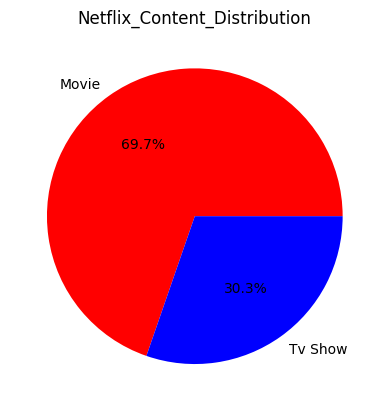

In [73]:
labels=['Movie','Tv Show']
size=[6126,2664]
colours=['red','blue']
plt.pie(size, labels=labels, autopct='%1.1f%%', colors=colours)
plt.title("Netflix_Content_Distribution")
plt.savefig('pie_chart.png')
plt.show()

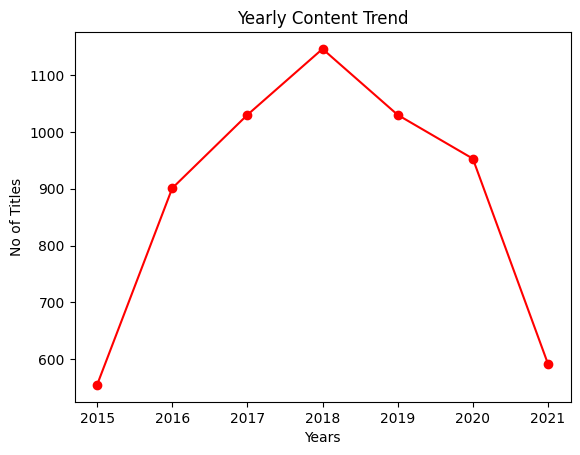

In [74]:
#peak trending years
years=[2015,2016,2017,2018,2019,2020,2021]
counts=[555,901,1030,1146,1030,953,592]
plt.plot(years,counts,marker='o',color='red')
plt.title("Yearly Content Trend")
plt.xlabel("Years")
plt.ylabel("No of Titles")
plt.savefig('yearly trend.png')
plt.show()

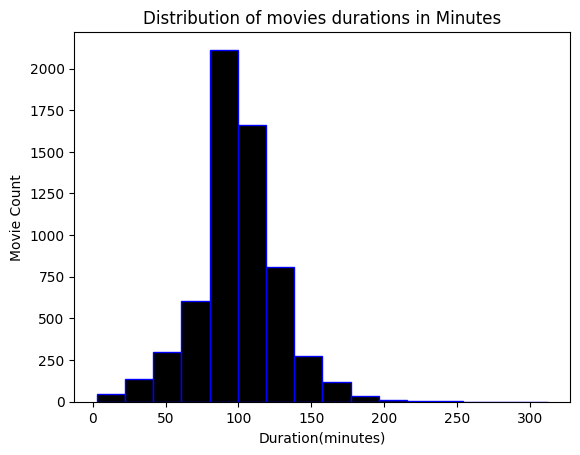

In [75]:
# histogram
movies_only=df[df['type']=='Movie'].copy()
plt.hist(movies_only['movie_duration_minute'],bins=16,color='black',edgecolor='blue')
plt.title("Distribution of movies durations in Minutes")
plt.xlabel("Duration(minutes)")
plt.ylabel("Movie Count")
plt.savefig('histogram.png')
plt.show()

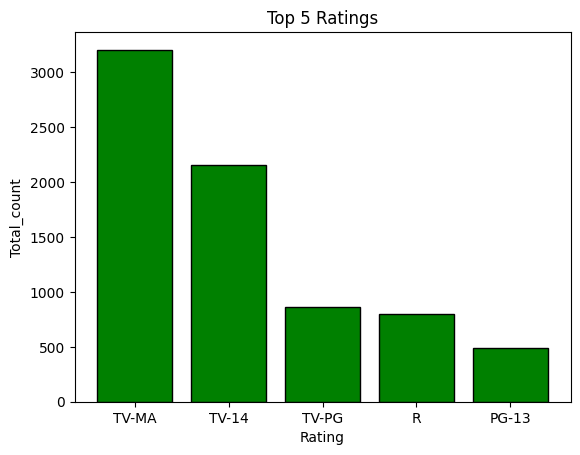

In [76]:
#bar chart
rating_count=df['rating'].value_counts().head(5)
plt.bar(rating_count.index,rating_count.values,color='green',edgecolor='black')
plt.title("Top 5 Ratings")
plt.xlabel("Rating")
plt.ylabel("Total_count")
plt.savefig('bar_chart.png')
plt.show()

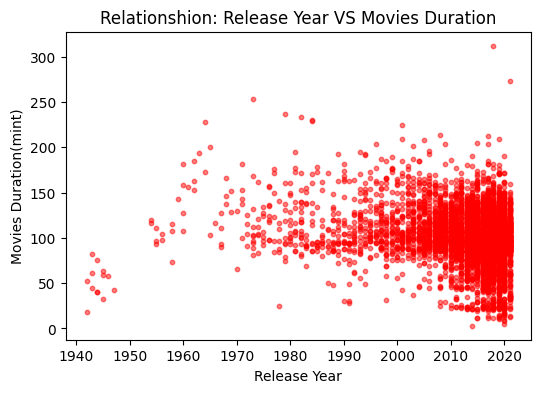

In [79]:
movies_only=df[df['type']=='Movie'].copy()
plt.figure(figsize=(6,4))
plt.scatter(movies_only['release_year'],movies_only['movie_duration_minute'],
            alpha=0.5,color='red',s=10)
plt.title("Relationshion: Release Year VS Movies Duration")
plt.xlabel("Release Year")
plt.ylabel("Movies Duration(mint)")
plt.savefig('scatter_chart.png')
plt.show()

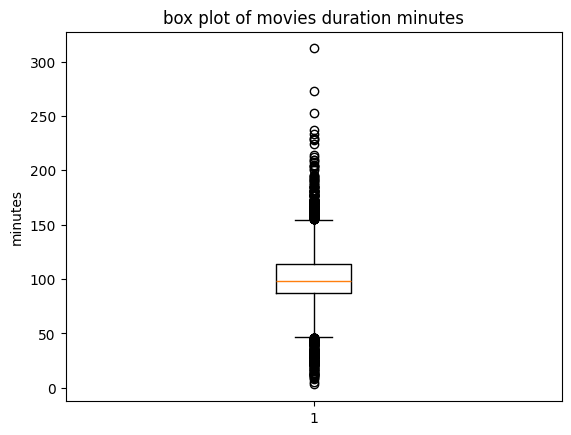

In [78]:
plt.boxplot(movies_only['movie_duration_minute'].dropna())
plt.title("box plot of movies duration minutes")
plt.ylabel("minutes")
plt.savefig('box_chart.png')
plt.show()
